# SMOTE: Handling Class Imbalance in Fraud Detection

This notebook applies SMOTE (Synthetic Minority Over-sampling Technique) to address the severe class imbalance in our fraud detection dataset. SMOTE generates synthetic samples of the minority class (fraudulent transactions) by interpolating between existing minority class examples.


## 1. Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from collections import Counter

# Set random seed for reproducibility
np.random.seed(42)

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('Set2')

## 2. Load Dataset

Load the dataset from Kaggle. Make sure the dataset is in the correct path.

In [6]:
import kagglehub
import os
import shutil

# Create the data/raw directory if it doesn't exist
os.makedirs("../data/raw", exist_ok=True)

path = kagglehub.dataset_download("sriharshaeedala/financial-fraud-detection-dataset")
print("Dataset downloaded to:", path)

target_dir = "../data/raw/financial-fraud-detection-dataset"
if os.path.exists(target_dir):
    shutil.rmtree(target_dir)
shutil.copytree(path, target_dir)
print(f"Dataset copied to: {target_dir}")

path = target_dir

/Users/angjiayi/code/DSA4263/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset downloaded to: /Users/angjiayi/.cache/kagglehub/datasets/sriharshaeedala/financial-fraud-detection-dataset/versions/1
Dataset copied to: ../data/raw/financial-fraud-detection-dataset


In [7]:
import pandas as pd
import os

csv_file = os.path.join(path, "Synthetic_Financial_datasets_log.csv")
print(f"Looking for file at: {csv_file}")


df = pd.read_csv(csv_file)
print("Shape:", df.shape)
print(df.head())
print(df.info())


Looking for file at: ../data/raw/financial-fraud-detection-dataset/Synthetic_Financial_datasets_log.csv
Shape: (6362620, 11)
   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        

## 3. Feature Engineering

Recreate the key features identified in the EDA phase.

In [8]:
# Create day feature
df['day'] = df['step'] // 24

# Network features
df['distinctNameDest_perSender'] = df.groupby('nameOrig')['nameDest'].transform('nunique')
df['distinctNameOrig_perReceiver'] = df.groupby('nameDest')['nameOrig'].transform('nunique')

# Average amount to destination
df['avgAmountToDest'] = df.groupby(['nameOrig', 'nameDest'])['amount'].transform('mean')

# Number of repeat transactions
df['numRepeatTxnsWithDest'] = df.groupby(['nameOrig', 'nameDest'])['amount'].transform('count')

# Time since last transaction
df = df.sort_values(['nameOrig', 'step']).reset_index(drop=True)
df['timeSinceLastTransaction'] = df.groupby('nameOrig')['step'].diff().fillna(999)

# Same user transaction flag
df['sameUserTransaction'] = (df['nameOrig'] == df['nameDest']).astype(int)

# Sender aggregations
sender_agg = df.groupby('nameOrig').agg(
    totalSent=('amount', 'sum'),
    meanSent=('amount', 'mean'),
    stdSent=('amount', 'std'),
    numSent=('amount', 'count')
).reset_index()
df = df.merge(sender_agg, on='nameOrig', how='left')

# Receiver aggregations
receiver_agg = df.groupby('nameDest').agg(
    totalReceived=('amount', 'sum'),
    meanReceived=('amount', 'mean'),
    stdReceived=('amount', 'std'),
    numReceived=('amount', 'count')
).reset_index()
df = df.merge(receiver_agg, on='nameDest', how='left')

# Transaction type fractions for senders
type_sender = df.groupby(['nameOrig', 'type']).size().unstack(fill_value=0)
type_sender = type_sender.div(type_sender.sum(axis=1), axis=0)
type_sender.columns = [f'fraction_{col}' for col in type_sender.columns]
df = df.merge(type_sender, left_on='nameOrig', right_index=True, how='left')

# Transaction type fractions for receivers
type_receiver = df.groupby(['nameDest', 'type']).size().unstack(fill_value=0)
type_receiver = type_receiver.div(type_receiver.sum(axis=1), axis=0)
type_receiver.columns = [f'fraction_{col}_recv' for col in type_receiver.columns]
df = df.merge(type_receiver, left_on='nameDest', right_index=True, how='left')

# Fraud ratios
fraud_by_receiver = df.groupby('nameDest')['isFraud'].mean().reset_index()
fraud_by_receiver.columns = ['nameDest', 'fraudRatioAmongReceivers']
df = df.merge(fraud_by_receiver, on='nameDest', how='left')

fraud_by_sender = df.groupby('nameOrig')['isFraud'].mean().reset_index()
fraud_by_sender.columns = ['nameOrig', 'fraudRatioAmongSenders']
df = df.merge(fraud_by_sender, on='nameOrig', how='left')

# Balance annihilation
df['isBalanceAnnihilation'] = ((df['oldbalanceOrg'] > 0) & (df['newbalanceOrig'] == 0)).astype(int)

print(f"\nFeature engineering complete. Dataset shape: {df.shape}")


Feature engineering complete. Dataset shape: (6362620, 39)


## 4. Prepare Features for Modeling

Select relevant features and handle categorical variables.

In [9]:
# Encode transaction type
df['type_encoded'] = df['type'].astype('category').cat.codes

# Select features for modeling
feature_columns = [
    'step', 'type_encoded', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
    'oldbalanceDest', 'newbalanceDest', 'day',
    'distinctNameDest_perSender', 'distinctNameOrig_perReceiver',
    'avgAmountToDest', 'numRepeatTxnsWithDest', 'timeSinceLastTransaction',
    'sameUserTransaction', 'totalSent', 'meanSent', 'stdSent', 'numSent',
    'totalReceived', 'meanReceived', 'stdReceived', 'numReceived',
    'fraudRatioAmongReceivers', 'fraudRatioAmongSenders', 'isBalanceAnnihilation'
]

# Add fraction columns (they may have different types)
fraction_cols = [col for col in df.columns if col.startswith('fraction_')]
feature_columns.extend(fraction_cols)

# Prepare X and y
X = df[feature_columns].copy()
y = df['isFraud'].copy()

# Handle missing values
X = X.fillna(0)

print(f"Features selected: {len(feature_columns)}")
print(f"\nFeature list: {feature_columns}")
print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")

Features selected: 35

Feature list: ['step', 'type_encoded', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'day', 'distinctNameDest_perSender', 'distinctNameOrig_perReceiver', 'avgAmountToDest', 'numRepeatTxnsWithDest', 'timeSinceLastTransaction', 'sameUserTransaction', 'totalSent', 'meanSent', 'stdSent', 'numSent', 'totalReceived', 'meanReceived', 'stdReceived', 'numReceived', 'fraudRatioAmongReceivers', 'fraudRatioAmongSenders', 'isBalanceAnnihilation', 'fraction_CASH_IN', 'fraction_CASH_OUT', 'fraction_DEBIT', 'fraction_PAYMENT', 'fraction_TRANSFER', 'fraction_CASH_IN_recv', 'fraction_CASH_OUT_recv', 'fraction_DEBIT_recv', 'fraction_PAYMENT_recv', 'fraction_TRANSFER_recv']

X shape: (6362620, 35)
y shape: (6362620,)


## 5. Check Class Distribution Before SMOTE

Original class distribution:
Non-fraud (0): 6,354,407 (99.87%)
Fraud (1): 8,213 (0.13%)

Imbalance ratio: 773.70:1


/var/folders/fv/jpyrhgqn0xxgp87qx4gdn69w0000gn/T/ipykernel_38212/2276587398.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Non-Fraud (0)', 'Fraud (1)'])
/var/folders/fv/jpyrhgqn0xxgp87qx4gdn69w0000gn/T/ipykernel_38212/2276587398.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Non-Fraud (0)', 'Fraud (1)'])


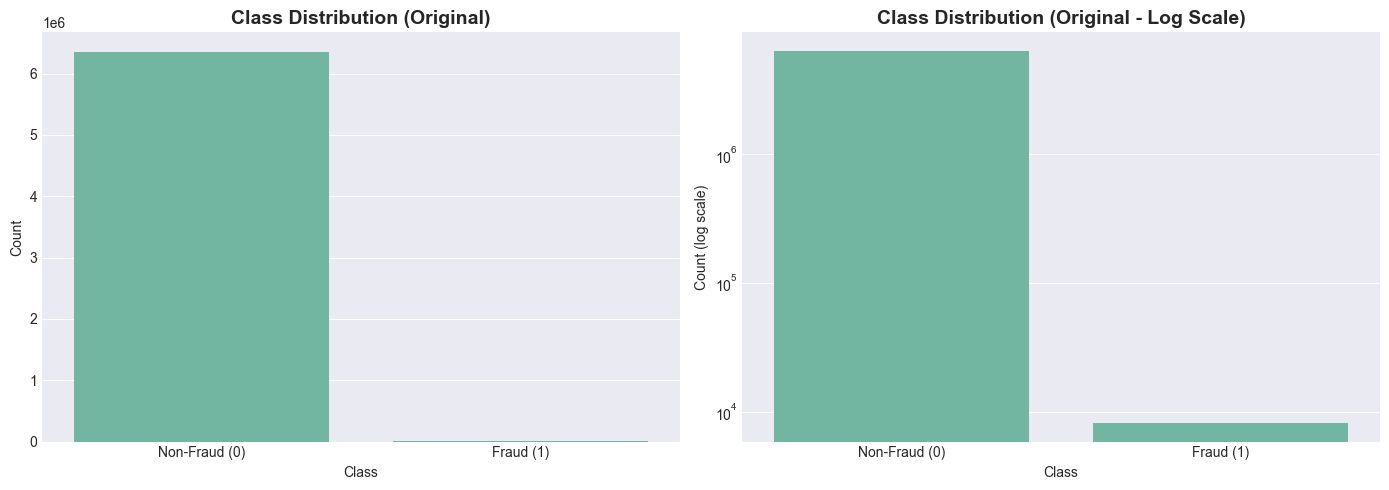

In [10]:
# Count class distribution
original_distribution = Counter(y)
print("Original class distribution:")
print(f"Non-fraud (0): {original_distribution[0]:,} ({original_distribution[0]/len(y)*100:.2f}%)")
print(f"Fraud (1): {original_distribution[1]:,} ({original_distribution[1]/len(y)*100:.2f}%)")
print(f"\nImbalance ratio: {original_distribution[0]/original_distribution[1]:.2f}:1")

# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sns.countplot(x=y, ax=axes[0])
axes[0].set_title('Class Distribution (Original)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Non-Fraud (0)', 'Fraud (1)'])

# Log scale plot
sns.countplot(x=y, ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title('Class Distribution (Original - Log Scale)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count (log scale)')
axes[1].set_xticklabels(['Non-Fraud (0)', 'Fraud (1)'])

plt.tight_layout()
plt.show()

## 6. Split Data Before SMOTE

**Important**: Split data into train/test sets BEFORE applying SMOTE to avoid data leakage. SMOTE should only be applied to the training set.

In [11]:
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]:,}")
print(f"Test set size: {X_test.shape[0]:,}")
print(f"\nTraining set class distribution:")
train_distribution = Counter(y_train)
print(f"Non-fraud: {train_distribution[0]:,} ({train_distribution[0]/len(y_train)*100:.2f}%)")
print(f"Fraud: {train_distribution[1]:,} ({train_distribution[1]/len(y_train)*100:.2f}%)")

Training set size: 5,090,096
Test set size: 1,272,524

Training set class distribution:
Non-fraud: 5,083,526 (99.87%)
Fraud: 6,570 (0.13%)


## 7. Apply SMOTE to Training Set

SMOTE generates synthetic samples by:
1. Selecting a minority class sample
2. Finding its k nearest neighbors (default k=5)
3. Randomly selecting one neighbor
4. Creating a synthetic sample along the line between the original sample and the selected neighbor

In [12]:
# Initialize SMOTE
smote = SMOTE(random_state=42, k_neighbors=5)

# Apply SMOTE to training data only
print("Applying SMOTE to training set...")
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"\nTraining set size after SMOTE: {X_train_smote.shape[0]:,}")
print(f"\nClass distribution after SMOTE:")
smote_distribution = Counter(y_train_smote)
print(f"Non-fraud: {smote_distribution[0]:,} ({smote_distribution[0]/len(y_train_smote)*100:.2f}%)")
print(f"Fraud: {smote_distribution[1]:,} ({smote_distribution[1]/len(y_train_smote)*100:.2f}%)")
print(f"\nBalance ratio: {smote_distribution[0]/smote_distribution[1]:.2f}:1")

Applying SMOTE to training set...

Training set size after SMOTE: 10,167,052

Class distribution after SMOTE:
Non-fraud: 5,083,526 (50.00%)
Fraud: 5,083,526 (50.00%)

Balance ratio: 1.00:1


## 8. Visualize Class Distribution Comparison

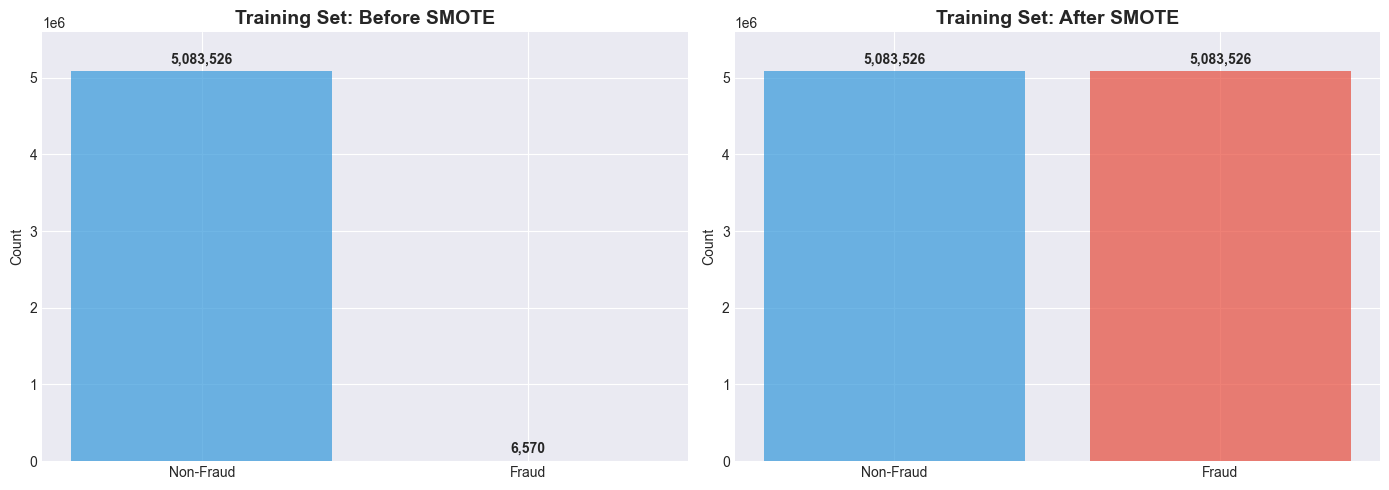


SUMMARY OF SMOTE APPLICATION
Original fraud samples: 6,570
Synthetic fraud samples generated: 5,076,956
Total fraud samples after SMOTE: 5,083,526

Increase in fraud samples: 77274.82%
Increase in total training samples: 99.74%


In [13]:
# Create comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before SMOTE
before_counts = [train_distribution[0], train_distribution[1]]
axes[0].bar(['Non-Fraud', 'Fraud'], before_counts, color=['#3498db', '#e74c3c'], alpha=0.7)
axes[0].set_title('Training Set: Before SMOTE', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, max(before_counts) * 1.1)
for i, v in enumerate(before_counts):
    axes[0].text(i, v + max(before_counts)*0.02, f'{v:,}', ha='center', fontweight='bold')

# After SMOTE
after_counts = [smote_distribution[0], smote_distribution[1]]
axes[1].bar(['Non-Fraud', 'Fraud'], after_counts, color=['#3498db', '#e74c3c'], alpha=0.7)
axes[1].set_title('Training Set: After SMOTE', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_ylim(0, max(after_counts) * 1.1)
for i, v in enumerate(after_counts):
    axes[1].text(i, v + max(after_counts)*0.02, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Show percentage change
print("\n" + "="*50)
print("SUMMARY OF SMOTE APPLICATION")
print("="*50)
print(f"Original fraud samples: {train_distribution[1]:,}")
print(f"Synthetic fraud samples generated: {smote_distribution[1] - train_distribution[1]:,}")
print(f"Total fraud samples after SMOTE: {smote_distribution[1]:,}")
print(f"\nIncrease in fraud samples: {((smote_distribution[1] - train_distribution[1]) / train_distribution[1] * 100):.2f}%")
print(f"Increase in total training samples: {((len(y_train_smote) - len(y_train)) / len(y_train) * 100):.2f}%")

## 9. Save Processed Data

Save the balanced training set and original test set for modeling.

In [14]:
# Create DataFrames for saving
X_train_smote_df = pd.DataFrame(X_train_smote, columns=feature_columns)
y_train_smote_df = pd.Series(y_train_smote, name='isFraud')

X_test_df = pd.DataFrame(X_test, columns=feature_columns)
y_test_df = pd.Series(y_test.values, name='isFraud')

# Save to CSV
train_smote_data = pd.concat([X_train_smote_df, y_train_smote_df], axis=1)
test_data = pd.concat([X_test_df, y_test_df], axis=1)

train_smote_data.to_csv('../data/train_smote.csv', index=False)
test_data.to_csv('../data/test.csv', index=False)

print("Data saved successfully!")
print(f"\nTrain (SMOTE) data: ../data/train_smote.csv")
print(f"  Shape: {train_smote_data.shape}")
print(f"\nTest data: ../data/test.csv")
print(f"  Shape: {test_data.shape}")

Data saved successfully!

Train (SMOTE) data: ../data/train_smote.csv
  Shape: (10167052, 36)

Test data: ../data/test.csv
  Shape: (2290721, 36)


## 10. Feature Distribution Analysis

Compare feature distributions between original fraud samples and synthetic fraud samples to verify SMOTE quality.

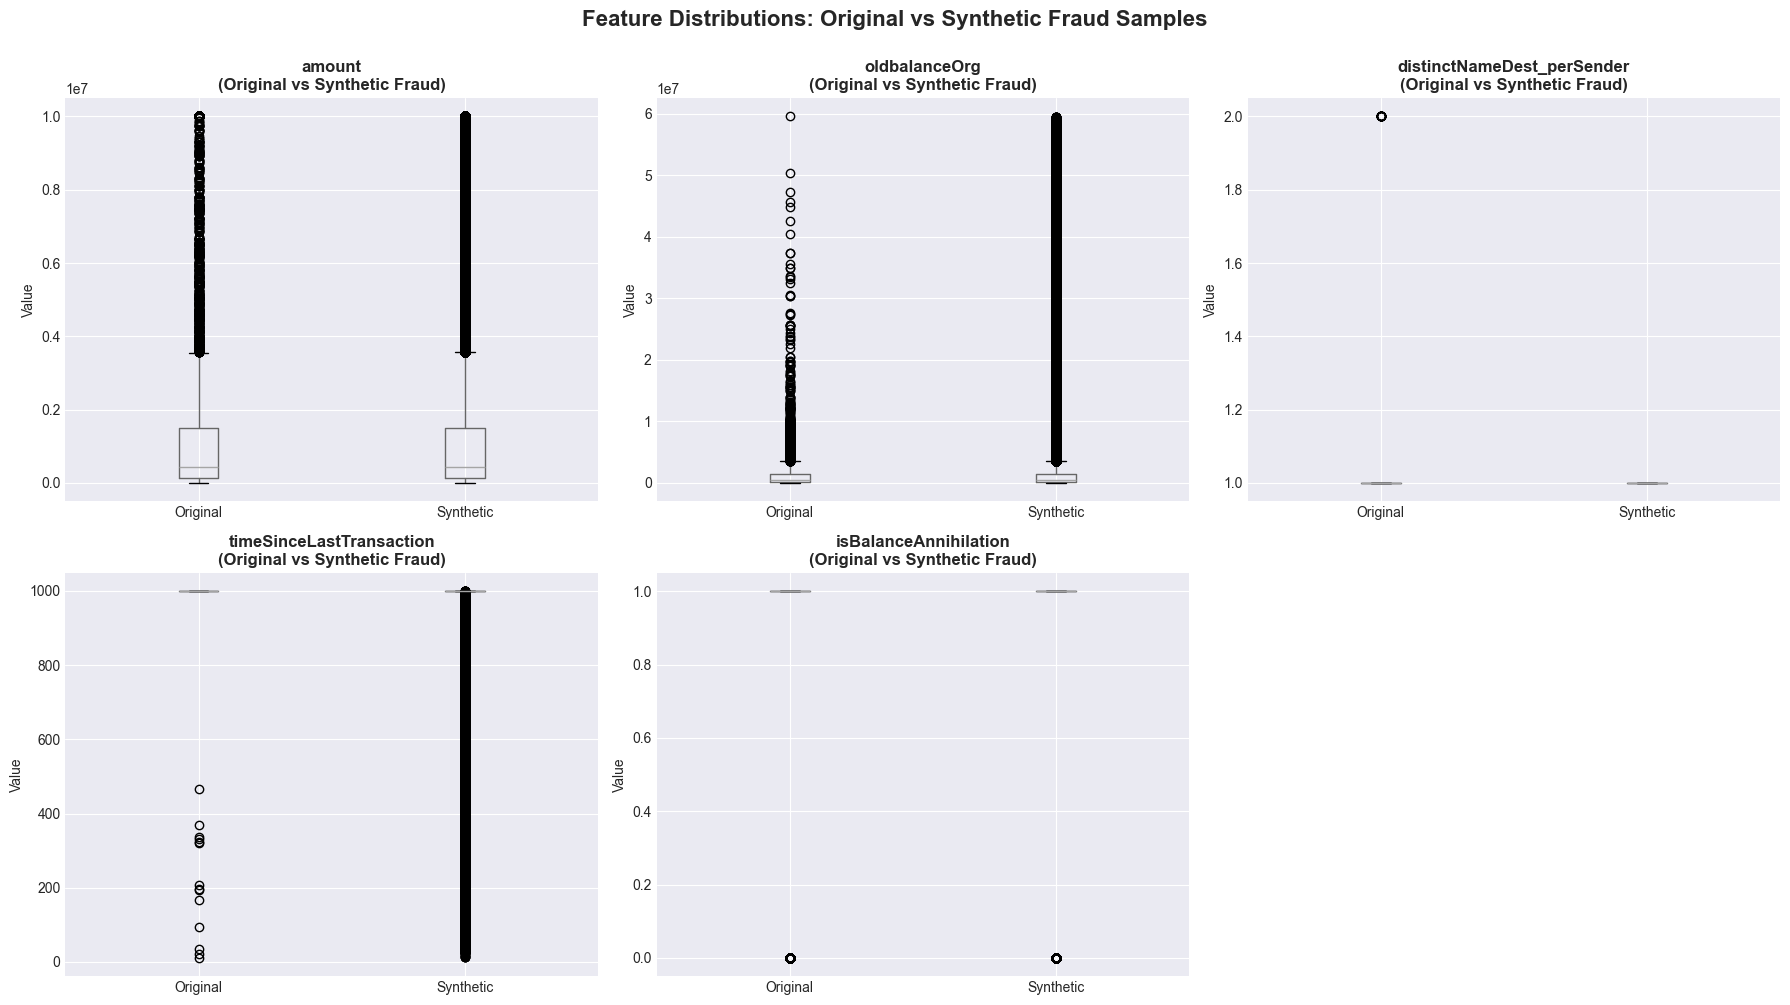

In [15]:
# Sample a few key features to compare
key_features = ['amount', 'oldbalanceOrg', 'distinctNameDest_perSender', 'timeSinceLastTransaction', 'isBalanceAnnihilation']

# Identify original vs synthetic fraud samples in SMOTE data
n_original_fraud = train_distribution[1]
fraud_indices = y_train_smote == 1

# Create labels: first n_original_fraud fraud samples are original, rest are synthetic
fraud_data = X_train_smote_df[y_train_smote == 1].copy()
fraud_data['source'] = ['Original'] * n_original_fraud + ['Synthetic'] * (len(fraud_data) - n_original_fraud)

# Plot distributions
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, feature in enumerate(key_features):
    if feature in fraud_data.columns:
        # Plot distributions for original vs synthetic
        fraud_data.boxplot(column=feature, by='source', ax=axes[idx])
        axes[idx].set_title(f'{feature}\n(Original vs Synthetic Fraud)', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('')
        axes[idx].set_ylabel('Value')
        plt.sca(axes[idx])
        plt.xticks(rotation=0)

# Remove the extra subplot
fig.delaxes(axes[5])

plt.suptitle('Feature Distributions: Original vs Synthetic Fraud Samples', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## Summary

### Key Takeaways:

1. **Class Balance**: SMOTE successfully balanced the training dataset by generating synthetic fraud samples
2. **Data Leakage Prevention**: SMOTE was applied only to the training set, keeping the test set untouched
3. **Feature Preservation**: Synthetic samples maintain similar feature distributions to original fraud samples


## Alternative SMOTE Strategies (If Results Are Suboptimal)

If model performance on the test set is not satisfactory, consider these SMOTE variants:

### 1. **Borderline-SMOTE**
```python
from imblearn.over_sampling import BorderlineSMOTE
smote = BorderlineSMOTE(random_state=42, k_neighbors=5)
```
**Why this might help**: Fraudsters often operate near the boundary of legitimate behavior to avoid detection. Borderline-SMOTE focuses on generating synthetic samples near the decision boundary where misclassification is most likely, rather than wasting resources on "easy" fraud cases that are obviously fraudulent.

**Best for**: Cases where the model struggles with fraud transactions that look similar to legitimate ones.

---

### 2. **ADASYN (Adaptive Synthetic Sampling)**
```python
from imblearn.over_sampling import ADASYN
smote = ADASYN(random_state=42, n_neighbors=5)
```
**Why this might help**: EDA revealed multiple distinct fraud patterns (balance annihilation, burst behavior, self-transfers, etc.). Some patterns may be harder to learn than others. ADASYN adaptively generates more synthetic samples in harder-to-learn regions where minority samples are surrounded by majority samples.

**Best for**: When different fraud patterns have varying levels of difficulty to detect.

---

### 3. **SMOTE-Tomek**
```python
from imblearn.combine import SMOTETomek
smote = SMOTETomek(random_state=42)
```
**Why this might help**: With 6.3 million transactions and only 8,213 fraud cases (0.13%), there's likely noise and ambiguous cases near class boundaries. SMOTE-Tomek first applies SMOTE, then removes Tomek links (pairs of opposite-class samples that are each other's nearest neighbors), creating cleaner decision boundaries.

**Best for**: Reducing overlap and noise between fraud and non-fraud classes.

---

### 4. **SMOTE-ENN (More Aggressive Cleaning)**
```python
from imblearn.combine import SMOTEENN
smote = SMOTEENN(random_state=42)
```
**Why this might help**: Similar to SMOTE-Tomek but uses Edited Nearest Neighbors for more aggressive cleaning. Removes samples whose class differs from the majority of their k-nearest neighbors.

**Best for**: Very noisy datasets where aggressive boundary cleaning is needed.

---

### Implementation Note:
Simply replace the SMOTE initialization in **Section 7** with any of the above alternatives and re-run from that cell onwards. All variants follow the same `fit_resample()` API, so no other code changes are needed.